In [1]:
import math, pylab, csv
import xarray as xr
import numpy as np
from datetime import datetime
from datetime import date
from itertools import groupby
from collections import Counter
from matplotlib.path import Path
import matplotlib.pyplot as plt
import earthaccess
import xarray as xr
from xarray.backends.api import open_datatree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
#%matplotlib widget
from scipy.ndimage import generic_filter
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata
import seaborn as sns 
import pandas

In [2]:
# %matplotlib widget

In [3]:
fontsize = 20

plt.rc('font', size=fontsize)          # controls default text sizes
plt.rc('axes', titlesize=fontsize)     # fontsize of the axes title
plt.rc('axes', labelsize=fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('ytick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('legend', fontsize=fontsize)    # legend fontsize
plt.rc('figure', titlesize=fontsize)  # fontsize of the figure title

In [4]:
date_requested = '20240508' #select date of common SWOT/PACE overlap
pacedate="2024-05-08"

In [5]:
ds = xr.open_dataset('/home/jovyan/go-swace/data/eddy_trajectories/Edward_Eddy_trajectory_nrt_3.2exp_cyclonic_20180101_20240723.nc')
specialid='eddy_IDedward'

In [34]:
moanapath='/home/jovyan/go-swace/data/moana/moana_Edward_05082024.nc'
datasetmoana = xr.open_dataset(moanapath) # should rename this with file extention .nc

In [7]:
dates = [i for i in ds.time.values] # these are sorted already
print(min(dates))
print(max(dates)) # still existed at the end of the dataset
tminny=str(min(dates))
tminny=tminny[0:10]
tmaxxy=str(max(dates))
tmaxxy=tmaxxy[0:10]
tmin,tmax = tminny,tmaxxy
center_lats = [i for i in ds.latitude.values]
center_lons = [i for i in ds.longitude.values]
print(len(center_lats))
#Define box based on eddy
latmin,latmax = min(center_lats)-2,max(center_lats)+2
lonmin,lonmax = min(center_lons)-360-2,max(center_lons)-360+2

2023-12-14T00:00:00.000000000
2024-07-23T00:00:00.000000000
223


In [8]:
def in_eddy(ds,float_lat,float_lon,float_time):
    """
    float_lat: degrees north
    float_lon: degrees east
    float_time: should be in format 'YYYY-MM-DD'
    """

    def all_equal(iterable):
        g = groupby(iterable)
        return next(g, True) and not next(g, False)

    in_eddy_flag = False 

    float_time = np.datetime64(float_time)
    if float_time in ds.time: # some dates not in dateset        
        for i in np.where(ds.time == float_time)[0]: # usually will only be 1 eddy, but sometimes there are 2 after a split
            contour_lons = np.array(ds.effective_contour_longitude[i]) # eddy lons
            contour_lats = np.array(ds.effective_contour_latitude[i]) # eddy lats
            
            if all_equal(contour_lons): # eddy break
                pass
            else:
                poly = Path([(contour_lats[j],contour_lons[j]) for j in np.arange(0,len(contour_lats))]) # set up the polygon
                if poly.contains_points([(float_lat,float_lon)]): #find if point is inside the polygon
                    in_eddy_flag = True 

    return in_eddy_flag

In [9]:
in_eddy(ds,35,289.5,'2024-05-08') #test

True

## To do: might have to change paths[1] to paths[0] or other depending on which is the clear image

In [52]:
# PACE CHL
results = earthaccess.search_datasets(instrument="oci")

tspan=(pacedate,pacedate)
bbox = (lonmin+2, latmin+2, lonmax-2, latmax-2)

clouds = (0, 100)
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_BGC",
    temporal=tspan,
    bounding_box=bbox,
    cloud_cover=clouds,
)

paths = earthaccess.open(results) #'streaming' data

datatree = open_datatree(paths[1])
datatree
dataset = xr.merge(datatree.to_dict().values())
dataset
dataset = dataset.set_coords(("longitude", "latitude"))

QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

## To do: Manually select box for 'outside of eddy' bounds

(-73.77410888671875, -65.88714599609375)

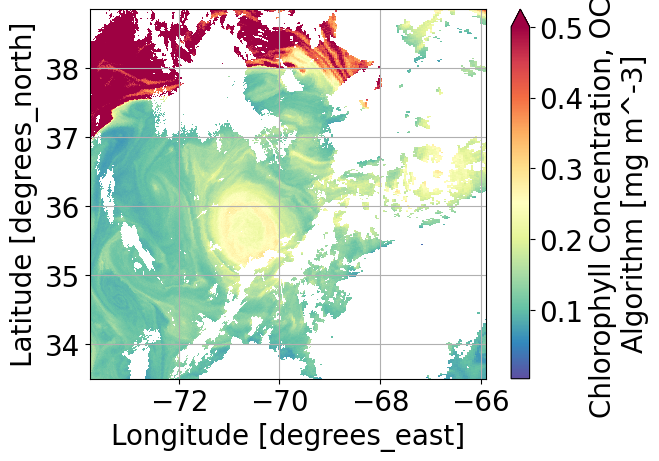

In [53]:
fig = plt.figure()
ax = plt.axes()#projection=ccrs.PlateCarree())
plot=dataset["chlor_a"].plot(x="longitude", y="latitude", cmap="Spectral_r", vmax=0.5, ax=ax) #tried adding ,transform=ccrs.PlateCarree()
ax.grid(True)
ax.set_ylim([latmin,latmax])
ax.set_xlim([lonmin,lonmax])

In [54]:
# crop swot xarray
# Create a mask for the desired latitude range
bboxmask = (-73, 34, -68, 37) #edward

In [56]:
mask = (dataset.longitude >= bboxmask[0]) & (dataset.longitude <= bboxmask[2]) & (dataset.latitude >= bboxmask[1]) & (dataset.latitude <= bboxmask[3])
print(mask.sum())
# Check if the mask is valid (non-empty)
if mask.sum() == 0:
    mask = (dataset.longitude >= bboxmask[0]) & (dataset.longitude <= bboxmask[2])
    if mask.sum() == 0:
        print('Mask via longitude only')
        mask = (dataset.latitude >= bboxmask[1]) & (dataset.latitude <= bboxmask[3])
        print(mask.sum())
    else:
        print('Mask via latitude only')
        print(mask.sum())
# Apply the mask to slice the dataset
ds_masked = dataset.where(mask, drop=True)

<xarray.DataArray ()> Size: 8B
array(61929)


In [57]:
lat=ds_masked.latitude.values.flatten()
lon=ds_masked.longitude.values.flatten()+360
chl=ds_masked.chlor_a.values.flatten()

chl_inside,chl_outside=[],[]

for index in np.arange(0,len(lat)):
    val=in_eddy(ds,lat[index],lon[index],pacedate)
    if val:
        chl_inside.append(chl[index])
        # chl_outside.append(np.nan)
    else:
        chl_outside.append(chl[index])
        # chl_inside.append(np.nan)

In [24]:
np.nanmean(chl_inside)

0.2110251

In [36]:
# Create a mask for the desired latitude range
mask = (datasetmoana.longitude >= bboxmask[0]) & (datasetmoana.longitude <= bboxmask[2]) & (datasetmoana.latitude >= bboxmask[1]) & (datasetmoana.latitude <= bboxmask[3])
print(mask.sum())
# Check if the mask is valid (non-empty)
if mask.sum() == 0:
    mask = (datasetmoana.longitude >= bboxmask[0]) & (datasetmoana.longitude <= bboxmask[2])
    if mask.sum() == 0:
        print('Mask via longitude only')
        mask = (datasetmoana.latitude >= bboxmask[1]) & (datasetmoana.latitude <= bboxmask[3])
        print(mask.sum())
    else:
        print('Mask via latitude only')
        print(mask.sum())
# Apply the mask to slice the dataset
ds_masked_moana = datasetmoana.where(mask, drop=True)

<xarray.DataArray ()> Size: 8B
array(61939)


In [37]:
pico=ds_masked_moana["picoeuk_moana"].values.flatten()
lon = ds_masked_moana['longitude'].values.flatten()+360
lat = ds_masked_moana['latitude'].values.flatten()
pro = ds_masked_moana['prococcus_moana'].values.flatten()
pico = ds_masked_moana['picoeuk_moana'].values.flatten()
syn = ds_masked_moana['syncoccus_moana'].values.flatten()

In [ ]:
pico_out,pico_in,pro_in,pro_out,syn_in,syn_out=[],[],[],[],[],[]

for index in np.arange(0,len(lat)):
    val=in_eddy(ds,lat[index],lon[index],pacedate)
    if val:
        pico_in.append(pico[index])
        pro_in.append(pro[index])
        syn_in.append(syn[index])
    else:
        pico_out.append(pico[index])
        pro_out.append(pro[index])
        syn_out.append(syn[index])

In [ ]:
np.nanmean(pico_in)

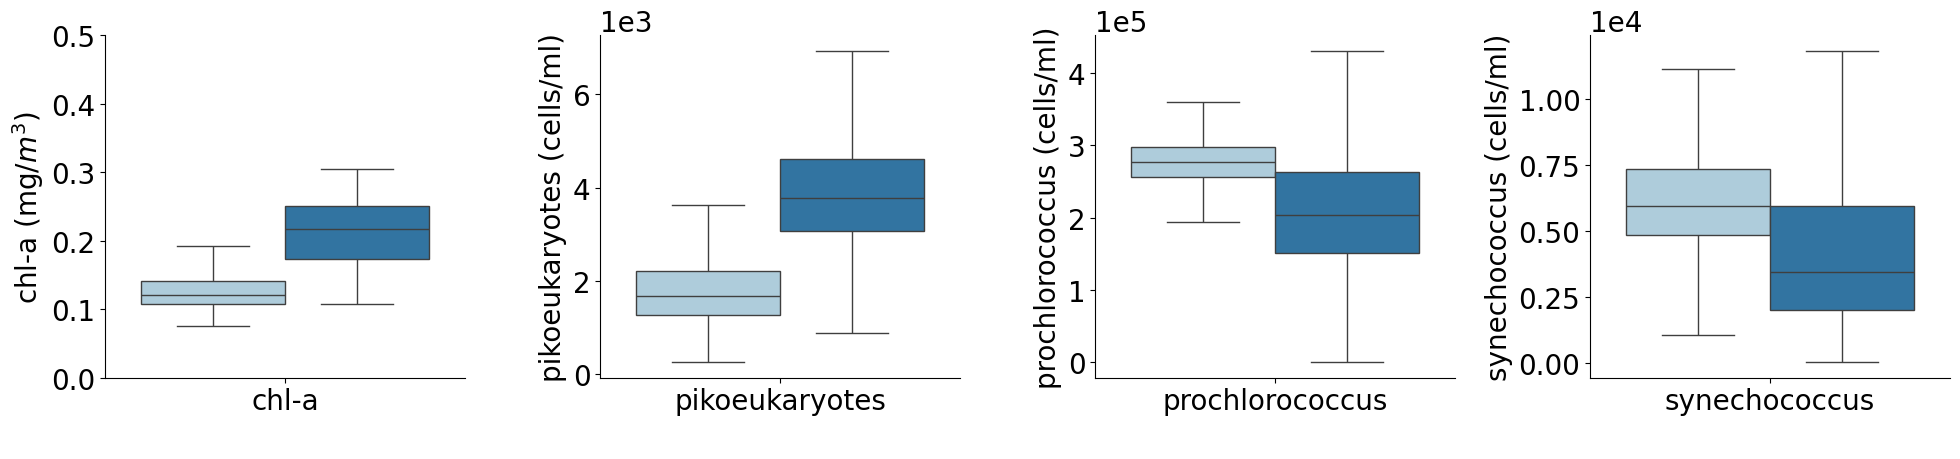

In [58]:
var=np.concatenate([np.repeat('chl-a',len(chl_outside)),np.repeat('chl-a',len(chl_inside))])
outin=np.concatenate([np.repeat('Outside',len(chl_outside)),np.repeat('Inside',len(chl_inside))]) 
value=np.concatenate([chl_outside,chl_inside])
d = {'var': var, 'outin': outin, 'value': value}
data = pandas.DataFrame(data=d)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20,5))

ax1=sns.boxplot(x = data['var'], 
            y = data['value'], 
            hue = data['outin'],showfliers=False, ax=ax1,palette="Paired")
ax1.set(ylim=[0,0.5])
ax1.set(xlabel=' ', ylabel='chl-a (mg/$m^{3}$)')
ax1.legend([],[], frameon=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

var=np.concatenate([np.repeat('pikoeukaryotes',len(pico_out)),np.repeat('pikoeukaryotes',len(pico_in))])
outin=np.concatenate([np.repeat('Outside',len(pico_out)),np.repeat('Inside',len(pico_in))]) 
value=np.concatenate([pico_out,pico_in])
d = {'var': var, 'outin': outin, 'value': value}
data = pandas.DataFrame(data=d)

ax2=sns.boxplot(x = data['var'], 
            y = data['value'], 
            hue = data['outin'],showfliers=False, ax=ax2,palette="Paired")
ax2.set(xlabel=' ', ylabel='pikoeukaryotes (cells/ml)')
ax2.legend([],[], frameon=False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))


var=np.concatenate([np.repeat('prochlorococcus',len(pro_out)),np.repeat('prochlorococcus',len(pro_in))])
outin=np.concatenate([np.repeat('Outside',len(pro_out)),np.repeat('Inside',len(pro_in))]) 
value=np.concatenate([pro_out,pro_in])
d = {'var': var, 'outin': outin, 'value': value}
data = pandas.DataFrame(data=d)

ax3=sns.boxplot(x = data['var'], 
            y = data['value'], 
            hue = data['outin'],showfliers=False, ax=ax3,palette="Paired")
ax3.set(xlabel=' ', ylabel='prochlorococcus (cells/ml)')
ax3.legend([],[], frameon=False)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))


var=np.concatenate([np.repeat('synechococcus',len(syn_out)),np.repeat('synechococcus',len(syn_in))])
outin=np.concatenate([np.repeat('Outside',len(syn_out)),np.repeat('Inside',len(syn_in))]) 
value=np.concatenate([syn_out,syn_in])
d = {'var': var, 'outin': outin, 'value': value}
data = pandas.DataFrame(data=d)

ax4=sns.boxplot(x = data['var'], 
            y = data['value'], 
            hue = data['outin'],showfliers=False, ax=ax4,palette="Paired")
ax4.set(xlabel=' ', ylabel='synechococcus (cells/ml)')
ax4.legend([],[], frameon=False)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))




plt.tight_layout()

# sns.color_palette()
